# Stage 3 — Persistent FeatureState memory

This notebook runs Shi–Tomasi detection on one synchronized DAVIS APS frame, allocates the resulting positions into fixed-capacity `FeatureStateMemory`, and visualizes the initialized valid states. State records have fixed-width numeric fields `[id:int32, x:float32, y:float32, vx:float32, vy:float32, confidence:float32, timestamp:int64, valid:uint8]`. Invalid records use `id=-1`, zero for all other values, and `valid=0`. Timestamps retain Stage 1's integer microsecond units; velocity is pixels per microsecond.

APS detections initialize velocity to zero and confidence to 1.0. This stage includes no event association or event processing.

In [1]:
import importlib
import sys
from pathlib import Path

project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src" / "feature_state_memory.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.davis_inspection import DavisConfig, load_davis
import src.frame_synchronization as frame_synchronization
frame_synchronization = importlib.reload(frame_synchronization)
import src.feature_state_memory as feature_state_memory
feature_state_memory = importlib.reload(feature_state_memory)
from src.aps_features import get_aps_frame

dataset_config = DavisConfig()
recording = load_davis(dataset_config)
origins_s, _ = frame_synchronization.load_timestamp_origins(recording, dataset_config)
windows = frame_synchronization.make_frame_windows(recording, origins_s)
frame_index = (len(windows) + 1) // 2
frame, timestamp_us = get_aps_frame(windows, frame_index)
features, memory = feature_state_memory.run_initialization(
    frame,
    timestamp_us,
    feature_count=500,
    slot_count=500,
)
configuration = {
    "recording": "shapes_6dof",
    "feature_count": 500,
    "timestamp_us": timestamp_us,
    "slot_count": memory.slot_count,
}
outputs = feature_state_memory.save_initialization_outputs(
    frame, features, memory, frame_index, feature_state_memory.DEFAULT_OUTPUT_DIR, configuration
)
print(f"Frame {frame_index} at {timestamp_us} us: {len(memory.get_active())} active states")
print(f"Storage shape: {memory.storage.shape}; dtype: {memory.storage.dtype}")
outputs

Frame 678 at 29876317 us: 500 active states
Storage shape: (500,); dtype: [('id', '<i4'), ('x', '<f4'), ('y', '<f4'), ('vx', '<f4'), ('vy', '<f4'), ('confidence', '<f4'), ('timestamp', '<i8'), ('valid', 'u1')]


{'states': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/feature_state_memory/davis_feature_states.npz'),
 'configuration': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/feature_state_memory/davis_feature_state_configuration.json'),
 'visualization': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/feature_state_memory/davis_feature_state_initialization.png'),
 'report': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/feature_state_memory/davis_feature_state_report.md')}

# Stage 3 — Persistent FeatureState memory initialization

- APS frame index: 678
- Requested Shi-Tomasi features: 500
- Detected features: 500
- Fixed state slots: 500
- Active initialized states: 500
- State timestamp: 29876317 microseconds
- State velocity: initialized to 0 pixels per microsecond.
- Confidence: initialized to 1.0 for each valid APS detection.
- Unused slots: `id=-1`, numeric fields zero, `valid=0`.
- No image patches, event association, or event processing are included.

The NPZ contains the full fixed-capacity `states` array, an `active_states` compact view, and the originating Stage 2A detections. All state fields use fixed-width numeric dtypes suitable for a BRAM-oriented layout.


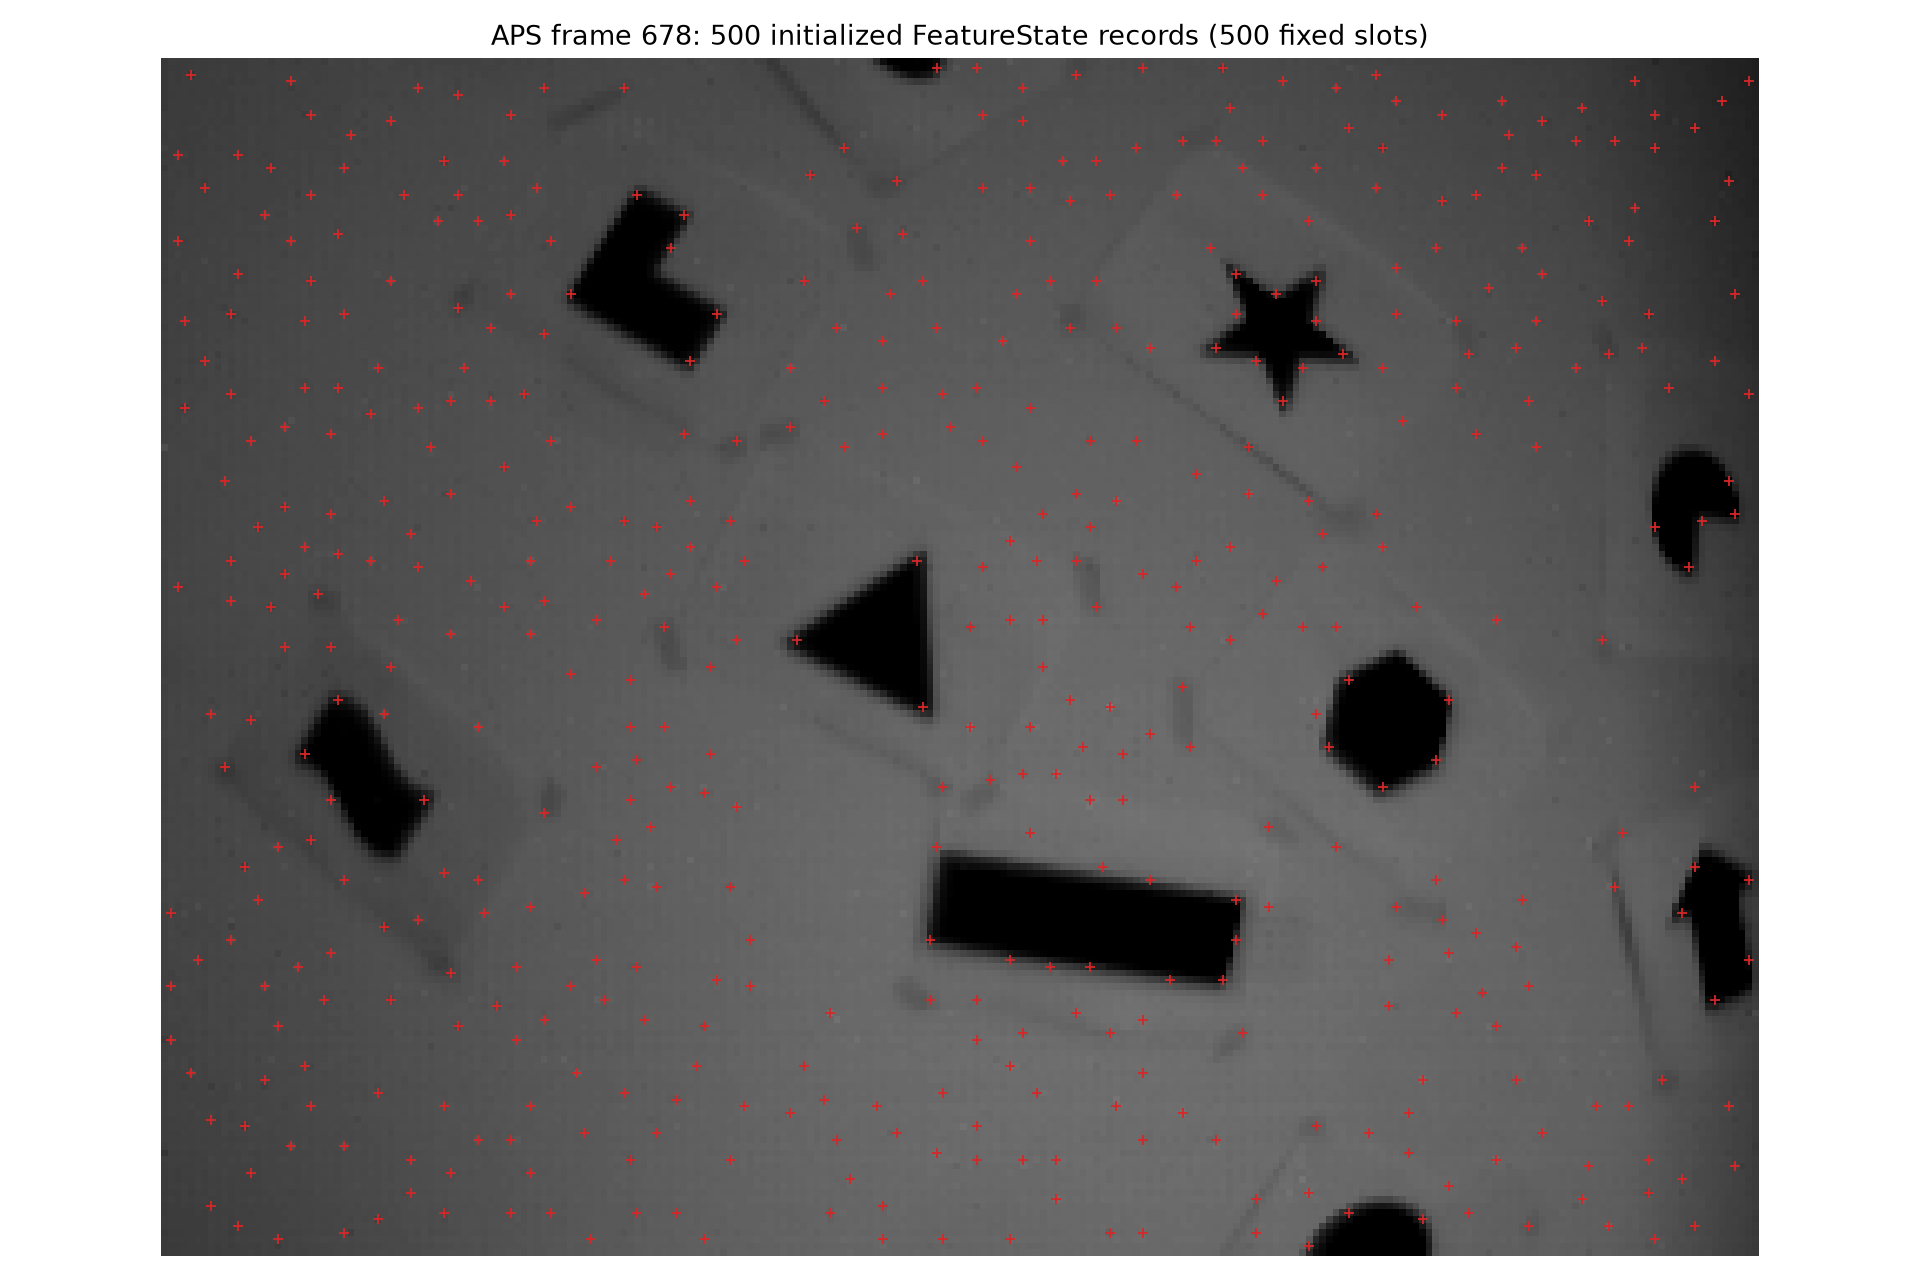

In [2]:
from IPython.display import Image, Markdown, display

display(Markdown(outputs["report"].read_text()))
display(Image(filename=str(outputs["visualization"])))